Feature engineering

In [ ]:
import sys
sys.path.append('..')

import lightgbm
import pandas as pd
from src.feature_engineering import build_features, temporal_split

df = pd.read_csv('../data/paysim_transactions.csv')
features = build_features(df)
features.head()

,amount,oldbalanceOrg,oldbalanceDest,newbalanceDest,hour_of_day,txn_count_1h,txn_count_24h,txn_count_7d,txn_amount_1h,txn_amount_24h,txn_amount_7d,step,isFraud
0,9839.64,170136.0,0.0,0.0,1,0,0,0,0.0,0.0,0.0,1,0
1,1864.28,21249.0,0.0,0.0,1,0,0,0,0.0,0.0,0.0,1,0
2,181.00,181.0,0.0,0.0,1,0,0,0,0.0,0.0,0.0,1,1
3,181.00,181.0,21182.0,0.0,1,0,0,0,0.0,0.0,0.0,1,1
4,11668.14,41554.0,0.0,0.0,1,0,0,0,0.0,0.0,0.0,1,0


In [2]:
example = df[df['nameOrig'] == 'C363736674'].sample(frac=1, random_state=1)
example[['step', 'type', 'amount', 'nameOrig']]

,step,type,amount,nameOrig
3188707,240,PAYMENT,17597.57,C363736674
5560270,384,PAYMENT,8020.14,C363736674
5375101,376,PAYMENT,43108.62,C363736674


In [3]:
build_features(example)[
    ['step', 'amount', 'txn_count_1h', 'txn_amount_1h', 'txn_count_24h', 'txn_amount_24h', 'txn_count_7d', 'txn_amount_7d']
].sort_values('step')

,step,amount,txn_count_1h,txn_amount_1h,txn_count_24h,txn_amount_24h,txn_count_7d,txn_amount_7d
3188707,240,17597.57,0,0.0,0,0.00,0,0.00
5375101,376,43108.62,0,0.0,0,0.00,1,17597.57
5560270,384,8020.14,0,0.0,1,43108.62,2,60706.19


Temporal split

In [4]:
train, test = temporal_split(features, train_frac=0.8)
print('train:', train.shape, 'step', train['step'].min(), '-', train['step'].max())
print('test:', test.shape, 'step', test['step'].min(), '-', test['step'].max())

train: (6239040, 13) step 1 - 594
test: (123580, 13) step 595 - 743


Train classifier

In [5]:
import time
from src.model import train_model

X_train = train.drop(columns=['isFraud'])
y_train = train['isFraud']

t0 = time.time()
model = train_model(X_train, y_train)
training_time_sec = time.time() - t0

print('training_time_sec', training_time_sec)
pd.Series(model.feature_importances_, index=model.feature_name_).sort_values(ascending=False)

training_time_sec 11.919137239456177


oldbalanceOrg     1095
amount            1078
hour_of_day        292
oldbalanceDest     272
newbalanceDest     258
txn_count_24h        4
txn_amount_7d        1
txn_count_1h         0
txn_count_7d         0
txn_amount_1h        0
txn_amount_24h       0
dtype: int32

In [6]:
import os
import joblib

os.makedirs('../models', exist_ok=True)
model_path = '../models/lightgbm_model.joblib'
joblib.dump(model, model_path)

print(model_path)
print(os.path.getsize(model_path))

../models/lightgbm_model.joblib
357188


Evaluate

In [7]:
import numpy as np
from src.evaluate import pr_auc, precision_recall_at_k, fpr_at_recall, cost_based_metric

X_test = test.drop(columns=['isFraud', 'step'])
y_test = test['isFraud']
y_score = model.predict_proba(X_test)[:, 1]

print('pr_auc', pr_auc(y_test, y_score))

precision_100, recall_100 = precision_recall_at_k(y_test, y_score, k=100)
print('precision_at_100', precision_100)
print('recall_at_100', recall_100)

print('fpr_at_recall_0.8', fpr_at_recall(y_test, y_score, target_recall=0.8))

cost_based_metric(y_test, y_score, thresholds=np.arange(0.0, 1.01, 0.05))

pr_auc 0.9229118044353105
precision_at_100 1.0
recall_at_100 0.060459492140266025
fpr_at_recall_0.8 0.0015091120843790495


,threshold,tp,fp,fn,tn,prevented_fraud_value,friction_cost,net_benefit
0,0.00,1654,121926,0,0,827000.0,609630.0,217370.0
1,0.05,1653,11257,1,110669,826500.0,56285.0,770215.0
2,0.10,1653,8856,1,113070,826500.0,44280.0,782220.0
3,0.15,1653,7457,1,114469,826500.0,37285.0,789215.0
4,0.20,1653,6335,1,115591,826500.0,31675.0,794825.0
5,0.25,1652,5557,2,116369,826000.0,27785.0,798215.0
6,0.30,1651,4959,3,116967,825500.0,24795.0,800705.0
7,0.35,1651,4441,3,117485,825500.0,22205.0,803295.0
8,0.40,1651,4012,3,117914,825500.0,20060.0,805440.0
9,0.45,1648,3600,6,118326,824000.0,18000.0,806000.0


Explainability

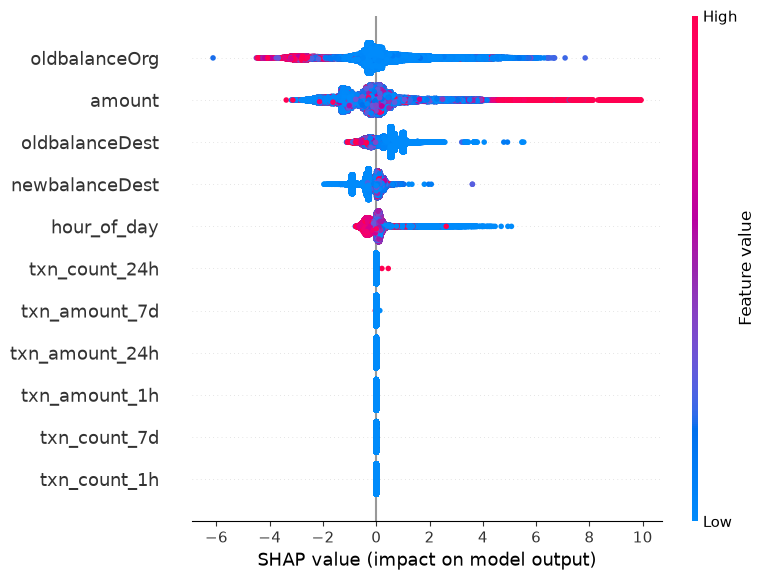

           feature  mean_abs_shap  is_velocity_feature
0    oldbalanceOrg       1.115858                False
1           amount       0.936714                False
2   oldbalanceDest       0.523212                False
3   newbalanceDest       0.294168                False
4      hour_of_day       0.284481                False
5    txn_count_24h       0.000075                 True
6    txn_amount_7d       0.000025                 True
7     txn_count_1h       0.000000                 True
8     txn_count_7d       0.000000                 True
9    txn_amount_1h       0.000000                 True
10  txn_amount_24h       0.000000                 True


,feature,feature_value,shap_value
0,oldbalanceOrg,236914.77,4.847853
1,amount,236914.77,3.843174
2,oldbalanceDest,0.00,2.337255
3,hour_of_day,19.00,-0.326626
4,newbalanceDest,0.00,-0.288305


In [8]:
%matplotlib inline
from src.explainability import summary_plot, explain_transaction

mean_abs_shap = summary_plot(model, X_test, show=True)
print(mean_abs_shap.to_string())

flagged_example = test[test['isFraud'] == 1].drop(columns=['isFraud', 'step']).iloc[[0]]
explain_transaction(model, flagged_example, top_n=5)